## Preparation

In [3]:
import sys
sys.path.append('../../../')
from tqdm import tqdm
import torch
import pandas as pd
import torch.nn.functional as F
import numpy as np
from datetime import datetime
from utilities import EarlyStopping, print_exams
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from bio_tokenizer import BioTokenizer
from transformers import MegaConfig, MegaForSequenceClassification
from MEGA_utilities import count_parameters
from tqdm import tqdm

class HANADataset(Dataset):
    def __init__(self, DataFrame):
        self.sequence = (DataFrame['seq_a'] + '<eos>' + DataFrame['seq_b'] + '<eos>' + DataFrame['seq_c'] + '<eos>' + DataFrame['seq_d'] + \
                         '<eos>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat']).tolist()
        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.sequence[idx], self.labels[idx]


## Test HA_and_NA model in Crick data

In [2]:
test_data = pd.read_csv('../../../data/MEGA_data/test_data.csv')

test_data_H1N1 = test_data[test_data['Type'] == 'H1N1']
test_data_H3N2 = test_data[test_data['Type'] == 'H3N2']
test_dataset_H1N1 = HANADataset(test_data_H1N1)
test_dataset_H3N2 = HANADataset(test_data_H3N2)
test_loader_H1N1 = DataLoader(test_dataset_H1N1, batch_size=128, shuffle=False)
test_loader_H3N2 = DataLoader(test_dataset_H3N2, batch_size=128, shuffle=False)

# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')

In [6]:
device = torch.device('cuda:1')
H1N1_model = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.3_H1N1_only_model/2025-10-22_14-39-42.pth', weights_only=False, map_location=device)
H3N2_model = torch.load('/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/trained_model/1.3_H3N2_only_model/2025-10-23_03-35-17.pth', weights_only=False, map_location=device)

In [4]:
from bio_tokenizer import BioTokenizer

# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')
H1N1_prediction_ls = []
H1N1_reference_ls = []
H1N1_logits_ls = []
H1N1_loss_ls_valid = []

H1N1_model.eval()
for batch_seq, batch_label in test_loader_H1N1:
    batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
    batch_input = batch_input.to(device)
    batch_label = batch_label.to(device)

    with torch.no_grad():
        outputs = H1N1_model(**batch_input, labels=batch_label)
    logits = outputs.logits
    loss = outputs.loss

    H1N1_logits_ls.append(logits)
    H1N1_loss_ls_valid.append(loss.item())
    H1N1_prediction_ls += logits.tolist()
    H1N1_prediction_ls_final = []
    for sublist in H1N1_prediction_ls:
        for element in sublist:
            H1N1_prediction_ls_final.append(element)
    H1N1_reference_ls += batch_label.tolist()


In [4]:
from bio_tokenizer import BioTokenizer

# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')
H1N1_prediction_ls = []
H1N1_reference_ls = []
H1N1_logits_ls = []
H1N1_loss_ls_valid = []

H1N1_model.eval()
for batch_seq, batch_label in test_loader_H3N2:
    batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
    batch_input = batch_input.to(device)
    batch_label = batch_label.to(device)

    with torch.no_grad():
        outputs = H1N1_model(**batch_input, labels=batch_label)
    logits = outputs.logits
    loss = outputs.loss

    H1N1_logits_ls.append(logits)
    H1N1_loss_ls_valid.append(loss.item())
    H1N1_prediction_ls += logits.tolist()
    H1N1_prediction_ls_final = []
    for sublist in H1N1_prediction_ls:
        for element in sublist:
            H1N1_prediction_ls_final.append(element)
    H1N1_reference_ls += batch_label.tolist()


In [5]:
H3N2_prediction_ls = []
H3N2_reference_ls = []
H3N2_logits_ls = []
H3N2_loss_ls_valid = []

H3N2_model.eval()
for batch_seq, batch_label in test_loader_H3N2:
    batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
    batch_input = batch_input.to(device)
    batch_label = batch_label.to(device)

    with torch.no_grad():
        outputs = H3N2_model(**batch_input, labels=batch_label)
    logits = outputs.logits
    loss = outputs.loss

    H3N2_logits_ls.append(logits)
    H3N2_loss_ls_valid.append(loss.item())
    H3N2_prediction_ls += logits.tolist()
    H3N2_prediction_ls_final = []
    for sublist in H3N2_prediction_ls:
        for element in sublist:
            H3N2_prediction_ls_final.append(element)
    H3N2_reference_ls += batch_label.tolist()


In [ ]:
from utilities import print_exams
print_exams(H1N1_reference_ls, H1N1_prediction_ls_final)
print_exams(H3N2_reference_ls, H3N2_prediction_ls_final)
print_exams(H1N1_reference_ls + H3N2_reference_ls, H1N1_prediction_ls_final + H3N2_prediction_ls_final)

MAE: 0.67266
MSE: 0.73073
pearson correlation: 0.87079
spearman correlation: 0.70300
R2_score: 0.66157
MAE: 0.70056
MSE: 0.85144
pearson correlation: 0.86371
spearman correlation: 0.86870
R2_score: 0.65524
MAE: 0.68559
MSE: 0.78664
pearson correlation: 0.89330
spearman correlation: 0.85914
R2_score: 0.73822


(0.685585696262019,
 0.7866444076991786,
 PearsonRResult(statistic=0.8932974599788589, pvalue=0.0),
 SignificanceResult(statistic=0.8591378651904521, pvalue=0.0),
 0.7382165490501984)

: 

## Test HA_and_NA data in CDC data

In [10]:
import pandas as pd

CDC_H1N1 = pd.read_excel('../../../data/raw/data4model(CDC-H1N1).xlsx')
CDC_H3N2 = pd.read_excel('../../../data/raw/data4model(CDC-H3N2).xlsx')
CDC_data = pd.concat([CDC_H1N1, CDC_H3N2])

In [11]:
## select required columns
CDC_H1N1_filt1 = CDC_H1N1[['serumName','virusName','serumHA', 'serumNA', 'virusHA', 'virusNA', 
                           'serumPassCat','virusPassCat', 'serumType','HI_Dist']].copy()
## remove duplicated row and mean HI_Dist
CDC_H1N1_filt2 = CDC_H1N1_filt1.groupby(['serumHA', 'serumNA', 'virusHA', 'virusNA', 'serumPassCat', 'virusPassCat']) \
        .agg({'serumName': 'first', 'virusName': 'first', 'serumType': 'first', 'HI_Dist': 'mean'}) \
        .reset_index()[['serumName', 'virusName', 'serumHA', 'serumNA', 'virusHA', 'virusNA',
                        'serumPassCat', 'virusPassCat', 'serumType', 'HI_Dist']]
## remove PassCat = 'BOTH'
CDC_H1N1_filt3 = CDC_H1N1_filt2[(CDC_H1N1_filt2['serumPassCat'] != 'BOTH') &
                              (CDC_H1N1_filt2['virusPassCat'] != 'BOTH')].reset_index(drop=True)
## replace PassCat to special token
CDC_H1N1_filt4 = CDC_H1N1_filt3.replace({'serumPassCat': {'EGG': '<EGG>', 'CELL': '<CELL>'},
                                       'virusPassCat': {'EGG': '<EGG>', 'CELL': '<CELL>'}})

CDC_H1N1_final = CDC_H1N1_filt4.copy()

## select required columns
CDC_H3N2_filt1 = CDC_H3N2[['serumName','virusName','serumHA', 'serumNA', 'virusHA', 'virusNA', 
                           'serumPassCat','virusPassCat', 'serumType','HI_Dist']].copy()
## remove duplicated row and mean HI_Dist
CDC_H3N2_filt2 = CDC_H3N2_filt1.groupby(['serumHA', 'serumNA', 'virusHA', 'virusNA', 'serumPassCat', 'virusPassCat']) \
        .agg({'serumName': 'first', 'virusName': 'first', 'serumType': 'first', 'HI_Dist': 'mean'}) \
        .reset_index()[['serumName', 'virusName', 'serumHA', 'serumNA', 'virusHA', 'virusNA',
                        'serumPassCat', 'virusPassCat', 'serumType', 'HI_Dist']]
CDC_H3N2_filt3 = CDC_H3N2_filt2[(CDC_H3N2_filt2['serumPassCat'] != 'BOTH') &
                              (CDC_H3N2_filt2['virusPassCat'] != 'BOTH')].reset_index(drop=True)
CDC_H3N2_filt4 = CDC_H3N2_filt3.replace({'serumPassCat': {'EGG': '<EGG>', 'CELL': '<CELL>'},
                                       'virusPassCat': {'EGG': '<EGG>', 'CELL': '<CELL>'}})

CDC_H3N2_final = CDC_H3N2_filt4.copy()

In [13]:
CDC_H1N1_dataset = AADataset(CDC_H1N1_final)
CDC_H1N1_loader = DataLoader(CDC_H1N1_dataset, batch_size=80, shuffle=False)

CDC_H3N2_dataset = AADataset(CDC_H3N2_final)
CDC_H3N2_loader = DataLoader(CDC_H3N2_dataset, batch_size=80, shuffle=False)

In [14]:
from bio_tokenizer import BioTokenizer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')
CDC_H1N1_prediction_ls = []
CDC_H1N1_reference_ls = []
CDC_H1N1_logits_ls = []
CDC_H1N1_loss_ls_valid = []
with torch.no_grad():
    H1N1_model.eval()
    for batch_seq, batch_label in CDC_H1N1_loader:
        batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
        batch_input = batch_input.to(device)
        batch_label = batch_label.to(device)

        outputs = H1N1_model(**batch_input, labels=batch_label)
        logits = outputs.logits
        loss = outputs.loss

        CDC_H1N1_logits_ls.append(logits)
        CDC_H1N1_loss_ls_valid.append(loss.item())
        CDC_H1N1_prediction_ls += logits.tolist()
        CDC_H1N1_prediction_ls_final = []
        for sublist in CDC_H1N1_prediction_ls:
            for element in sublist:
                CDC_H1N1_prediction_ls_final.append(element)
        CDC_H1N1_reference_ls += batch_label.tolist()
        

In [15]:
from bio_tokenizer import BioTokenizer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')
CDC_H3N2_prediction_ls = []
CDC_H3N2_reference_ls = []
CDC_H3N2_logits_ls = []
CDC_H3N2_loss_ls_valid = []
with torch.no_grad():
    H3N2_model.eval()
    for batch_seq, batch_label in CDC_H3N2_loader:
        batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
        batch_input = batch_input.to(device)
        batch_label = batch_label.to(device)

        outputs = H3N2_model(**batch_input, labels=batch_label)
        logits = outputs.logits
        loss = outputs.loss

        CDC_H3N2_logits_ls.append(logits)
        CDC_H3N2_loss_ls_valid.append(loss.item())
        CDC_H3N2_prediction_ls += logits.tolist()
        CDC_H3N2_prediction_ls_final = []
        for sublist in CDC_H3N2_prediction_ls:
            for element in sublist:
                CDC_H3N2_prediction_ls_final.append(element)
        CDC_H3N2_reference_ls += batch_label.tolist()
        

In [16]:
print('CDC H1N1 r2_score:',r2_score(CDC_H1N1_reference_ls, CDC_H1N1_prediction_ls_final))
print('CDC H3N2 r2_score:',r2_score(CDC_H3N2_reference_ls, CDC_H3N2_prediction_ls_final))
print('CDC H1N1 MAE:',mean_absolute_error(CDC_H1N1_reference_ls, CDC_H1N1_prediction_ls_final))
print('CDC H3N2 MAE:',mean_absolute_error(CDC_H3N2_reference_ls, CDC_H3N2_prediction_ls_final))
print('CDC H1N1 MSE:',mean_squared_error(CDC_H1N1_reference_ls, CDC_H1N1_prediction_ls_final))
print('CDC H3N2 MSE:',mean_squared_error(CDC_H3N2_reference_ls, CDC_H3N2_prediction_ls_final))
print('CDC H1N1 Pearson:',pearsonr(CDC_H1N1_reference_ls, CDC_H1N1_prediction_ls_final).statistic)
print('CDC H3N2 Pearson:',pearsonr(CDC_H3N2_reference_ls, CDC_H3N2_prediction_ls_final).statistic)
print('CDC H1N1 Spearman:',spearmanr(CDC_H1N1_reference_ls, CDC_H1N1_prediction_ls_final).statistic)
print('CDC H3N2 Spearman:',spearmanr(CDC_H3N2_reference_ls, CDC_H3N2_prediction_ls_final).statistic)

CDC H1N1 r2_score: 0.7030080020613976
CDC H3N2 r2_score: -0.08369785242201044
CDC H1N1 MAE: 0.9130357393910286
CDC H3N2 MAE: 1.5678438440297633
CDC H1N1 MSE: 1.379359299976584
CDC H3N2 MSE: 3.928314295164459
CDC H1N1 Pearson: 0.8438347478503655
CDC H3N2 Pearson: 0.2524610409259501
CDC H1N1 Spearman: 0.5627144707077414
CDC H3N2 Spearman: 0.2652869717123527


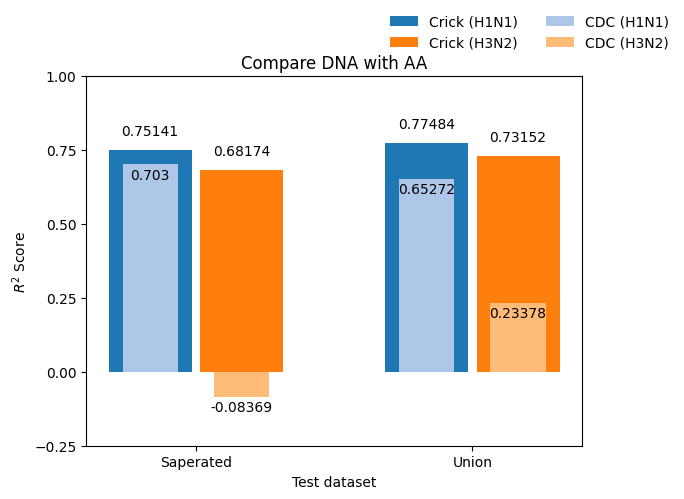

: 

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
samples = ['Saperated', 'Union']
datasets = ['Crick', 'CDC']
# AA and DNA use R2 score to evaluate the model

H1_data = {
    'Crick': [0.75141, 0.77484],
    'CDC': [0.70300, 0.65272]
}
H3_data = {
    'Crick': [0.68174, 0.73152],
    'CDC': [-0.08369, 0.23378]
}

# 设置柱状图的位置
x = np.arange(len(samples))

# 创建图形和轴
fig, ax = plt.subplots()

# 绘制每个波长的柱状图
colors_H1 = ['#1f77b4', '#aec7e8']  # 深蓝色和浅蓝色
colors_H3 = ['#ff7f0e', '#ffbb78']  # 橙色和浅橙色
widths = [0.3, 0.2]  # 设置每个柱子的宽度
dataset_drift = [0.05, -0.05]
for i, dataset in enumerate(datasets):
    ax.bar(x - widths[0]*1.1/2, H1_data[dataset], width=widths[i], label=dataset + ' (H1N1)', color=colors_H1[i], capsize=5)
    ax.text(x[0] - widths[0]*1.1/2, H1_data[dataset][0] + dataset_drift[i], str(H1_data[dataset][0]), ha='center')
    ax.text(x[1] - widths[0]*1.1/2, H1_data[dataset][1] + dataset_drift[i], str(H1_data[dataset][1]), ha='center')
    ax.bar(x + widths[0]*1.1/2, H3_data[dataset], width=widths[i], label=dataset + ' (H3N2)', color=colors_H3[i], capsize=5)
    ax.text(x[0] + widths[0]*1.1/2, H3_data[dataset][0] + dataset_drift[i], str(H3_data[dataset][0]), ha='center')
    ax.text(x[1] + widths[0]*1.1/2, H3_data[dataset][1] + dataset_drift[i], str(H3_data[dataset][1]), ha='center')



# 设置标签和标题
ax.set_xlabel('Test dataset')
ax.set_ylabel(r'$R^2$ Score')
ax.set_title('Compare DNA with AA')
ax.set_xticks(x)
ax.set_xticklabels(samples)
ax.set_yticks(np.arange(-0.25, 1.25, 0.25))
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.2), frameon=False, ncol=2)


# 显示图形
plt.savefig('1.2_test.png', dpi=300, bbox_inches='tight')

## 4. Future

In [9]:
test_data = pd.read_csv('../Crick_41_with_DNA.csv')
test_data_H1N1 = test_data[test_data['Type'] == 'H1N1']
test_data_H3N2 = test_data[test_data['Type'] == 'H3N2']
test_dataset_H1N1 = HANADataset(test_data_H1N1)
test_dataset_H3N2 = HANADataset(test_data_H3N2)
test_loader_H1N1 = DataLoader(test_dataset_H1N1, batch_size=128, shuffle=False)
test_loader_H3N2 = DataLoader(test_dataset_H3N2, batch_size=128, shuffle=False)

In [10]:
# get tokenizer and model
tokenizer = BioTokenizer(vocab_file='./vocab_AA.txt')
H1N1_prediction_ls = []
H1N1_reference_ls = []
H1N1_logits_ls = []
H1N1_loss_ls_valid = []

H1N1_model.eval()
for batch_seq, batch_label in test_loader_H1N1:
    batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
    batch_input = batch_input.to(device)
    batch_label = batch_label.to(device)

    with torch.no_grad():
        outputs = H1N1_model(**batch_input, labels=batch_label)
    logits = outputs.logits
    loss = outputs.loss

    H1N1_logits_ls.append(logits)
    H1N1_loss_ls_valid.append(loss.item())
    H1N1_prediction_ls += logits.tolist()
    H1N1_prediction_ls_final = []
    for sublist in H1N1_prediction_ls:
        for element in sublist:
            H1N1_prediction_ls_final.append(element)
    H1N1_reference_ls += batch_label.tolist()


In [11]:
H3N2_prediction_ls = []
H3N2_reference_ls = []
H3N2_logits_ls = []
H3N2_loss_ls_valid = []

H3N2_model.eval()
for batch_seq, batch_label in test_loader_H3N2:
    batch_input = tokenizer(batch_seq, padding='longest', return_tensors="pt")
    batch_input = batch_input.to(device)
    batch_label = batch_label.to(device)

    with torch.no_grad():
        outputs = H3N2_model(**batch_input, labels=batch_label)
    logits = outputs.logits
    loss = outputs.loss

    H3N2_logits_ls.append(logits)
    H3N2_loss_ls_valid.append(loss.item())
    H3N2_prediction_ls += logits.tolist()
    H3N2_prediction_ls_final = []
    for sublist in H3N2_prediction_ls:
        for element in sublist:
            H3N2_prediction_ls_final.append(element)
    H3N2_reference_ls += batch_label.tolist()


In [13]:
from utilities import print_exams
H1_result = print_exams(H1N1_reference_ls, H1N1_prediction_ls_final)
H3_result = print_exams(H3N2_reference_ls, H3N2_prediction_ls_final)
all_result = print_exams(H1N1_reference_ls + H3N2_reference_ls, H1N1_prediction_ls_final + H3N2_prediction_ls_final)

MAE: 0.82245
MSE: 0.98647
pearson correlation: 0.35978
spearman correlation: 0.38391
R2_score: -2.69173
MAE: 0.77192
MSE: 0.96705
pearson correlation: 0.33973
spearman correlation: 0.36030
R2_score: -1.39393
MAE: 0.80065
MSE: 0.97809
pearson correlation: 0.60381
spearman correlation: 0.61300
R2_score: -0.78105
